In [4]:
import jax.numpy as jnp
from jax import jit
import matplotlib.pyplot as plt

import typing
import h5py
import numpy as np
import jax
import os
from jax import vmap
import blackjax
import jax.numpy as jnp
import jax.random as random
from jax import jit
from tabulate import tabulate
from dataclasses import dataclass
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpecFromSubplotSpec

# Change the used font to the same LaTeX uses for consistency
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

import sys
import os

# Add the root project directory to the system path
sys.path.append(os.path.abspath(".."))
from ssps.ssp_data import SSPData

filename = '/Users/amanda/Desktop/PhD/Tools/ceridwen/data/test_data/ssp_data.h5'
ssp_data = SSPData.load(filename)





In [5]:

class CSPBasis:
    """
    A class to wrap the CSP object, providing the spectrum of a CSP for a given SFH.
    """

    def __init__(self, SSPData, tuniv=13.8, tiny_logt=-10, zidx=0, dust_params=None, **kwargs):
        """
        Initialize CSPBasis with the given SSPData object and optionally build a Dust model.

        Parameters:
            SSPData: An object holding SSP data (ages, metallicities, wavelengths, fluxes).
            tuniv: The age of the Universe in Gyr.
            tiny_logt: Smallest lookback time accepted.
            dust_params: Dictionary of parameters for initializing a Dust model (optional).
            kwargs: Additional keyword arguments (not used here, but available for future extensions).
        """
        
        self.flux = jnp.array(SSPData.ssp_flux)
        self.wave = jnp.array(SSPData.ssp_wave)
        self.ages = jnp.array(SSPData.ssp_lg_age_gyr)
        self.zmet = jnp.array(SSPData.ssp_lgmet)
        self.zlegend = 10**jnp.array(SSPData.ssp_lgmet)
        self.zidx = zidx  # Default: Use the first metallicity index

        self.time_full = self.ages + 9  # Convert from log(Gyr) to log(yr)
        self.tuniv = tuniv  # Age of the Universe in Gyr
        self.tiny_logt = tiny_logt  # Smallest lookback time we accept

        # If dust_params is provided, update it and initialize the Dust model
        self.dust_model = None  # Default: No dust model
        
    def __repr__(self):
        """
        Provide a string representation of the CSPBasis object.
        """
        repr_str = (
            f"<CSPBasis Object>\n"
            f"-----------------------------------\n"
            f"Universe Age (tuniv): {self.tuniv} Gyr\n"
            f"Tiny Log Time (tiny_logt): {self.tiny_logt}\n"
            f"Number of SSP Ages: {len(self.ages)}\n"
            f"Number of SSP Metallicities: {len(self.zmet)}\n"
            f"Wavelength Range: {self.wave.min()} - {self.wave.max()} Å\n"
        )
        
        if hasattr(self, "sfh"):
            repr_str += (
                f"Star Formation History:\n"
                f"  SFH Times (lookback): {self.sfh_times}\n"
                f"  SFH Values: {self.sfh}\n"
            )
        else:
            repr_str += "Star Formation History: Not added yet\n"
        
        if hasattr(self, "spectrum"):
            repr_str += "Spectrum: Computed\n"
        else:
            repr_str += "Spectrum: Not computed yet\n"

        return repr_str

    def add_sfh(self, sfh, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Add a star formation history to the CSP.

        Parameters:
            sfh: The star formation rate at the given ages.
            lookback_time: Array of lookback times for the SFH in Gyr.
            forward_time: Array of forward times (age of the universe) for the SFH in Gyr.
            tuniv: The age of the universe in Gyr.
        """
        sfh, sfh_times = add_sfh(sfh, lookback_time = lookback_time, forward_time = forward_time, tuniv=tuniv)  # Use the JIT-compiled pure function
        self.sfh = jnp.abs(sfh)
        self.sfh_times = sfh_times

    def change_history(self, sfh, zh, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Change the star formation history and metallicity history of the CSP.

        Parameters:
            sfh: The star formation rate at the given ages.
            zh: The metallicity at the given ages.
            lookback_time: Array of lookback times for the SFH in Gyr.
            forward_time: Array of forward times (age of the universe) for the SFH in Gyr.
            tuniv: The age of the universe in Gyr.
        """
        self.add_sfh(sfh, lookback_time=lookback_time, forward_time=forward_time, tuniv=tuniv)
        self.add_zh(zh, lookback_time=lookback_time, forward_time=forward_time, tuniv=tuniv)

        

    def add_zh(self, zh, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Add a metallicity history to the CSP.

        Parameters:
            zh: The metallicity at the given ages.
            lookback_time: Array of lookback times for the SFH in Gyr.
            forward_time: Array of forward times (age of the universe) for the SFH in Gyr.
            tuniv: The age of the universe in Gyr.
        """
        zh, zh_times = add_zh(zh=zh, lookback_time = lookback_time, forward_time = forward_time, tuniv=tuniv)  # Use the JIT-compiled pure function
        #check that the metallicity history is the same length as the SFH
        if self.sfh_times.shape != zh_times.shape:
            raise ValueError("The metallicity history must have the same length as the SFH.")
        self.sfh_times = zh_times
        self.zh = zh

    def get_spectrum(self, sfh=None, zh=None, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Get the spectrum of the CSP for the given SFH.
        """
        self.tuniv = tuniv
        if sfh is not None:
            self.add_sfh(sfh, lookback_time=lookback_time, forward_time=forward_time, tuniv=tuniv)
        if zh is not None:
            self.add_zh(zh, lookback_time=lookback_time, forward_time=forward_time, tuniv=tuniv)
        #if not hasattr(self, "ssp_weights"):
        self.ssp_weights = self.calculate_ssp_weights()
        flux = self.flux
        tiny_number = 1e-70
        valid_mask = self.ssp_weights > tiny_number  # Shape: (n_time, n_z)
        weight_ssp = jnp.where(valid_mask, self.ssp_weights, 0)

        # Compute temporary spectra (avoiding negative/zero values)
        spectrum = jnp.sum(self.ssp_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)
        #spectrum = jnp.trapezoid(flux[0, :, :] * ssp_weights[:, None], x=self.ages, axis=0) 
        self.spectrum = spectrum / (len(self.sfh) - 1) # Normalize by the number of time bins
        return spectrum
    
    def get_spectrum_dustbins(self, sfh=None, zh=None, dust_bins=None, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Get the spectrum of the CSP for the given SFH, applying different dust laws to different age bins.

        Parameters:
            sfh: Star Formation History (optional)
            zh: Metallicity History (optional)
            lookback_time: Lookback time array (optional)
            forward_time: Forward time array (optional)
            tuniv: Age of the Universe in Gyr (default: 13.8)
            dust_bins: List of tuples specifying age bins (e.g., [(-6, -4), (-4, -2), ...]) in log Gyr.

        Returns:
            Single spectrum if one dust bin is given, or a list of spectra if multiple bins are specified.
        """
        self.tuniv = tuniv
        if sfh is not None:
            self.add_sfh(sfh, lookback_time=lookback_time, forward_time=forward_time, tuniv=tuniv)
        if zh is not None:
            self.add_zh(zh, lookback_time=lookback_time, forward_time=forward_time, tuniv=tuniv)
        if dust_bins is not None:
            self.dust_bins = dust_bins
        
        self.ssp_weights = self.calculate_ssp_weights()

        ssp_weights = self.ssp_weights[..., None]  # Ensure correct broadcasting shape (12, 108, 1) or (1, 108, 1)
   
        if not hasattr(self, "dust_bins") or len(self.dust_bins) == 1:
            spectrum = jnp.sum(ssp_weights * self.flux, axis=(0, 1) if hasattr(self, "zh") else 0)
            self.spectrum = spectrum / (len(self.sfh) - 1)
            return spectrum

        else:  # Compute CSPs for each dust bin
            csp_spectra = []
            for bin_start, bin_end in self.dust_bins:
                bin_mask = (self.ages >= bin_start) & (self.ages < bin_end)  # Convert Myr to Gyr
                ssp_weights_bin = jnp.where(bin_mask[None, :], self.ssp_weights, 0)[..., None]

                spectrum_bin = jnp.sum(ssp_weights_bin * self.flux, axis=(0, 1) if hasattr(self, "zh") else 0)
                csp_spectra.append(spectrum_bin / (len(self.sfh) - 1))

            return csp_spectra
            
    def calculate_ssp_weights(self):
        """
        Get the spectrum of the CSP for the given SFH. The dimensions are: number of bins = i, number of ssp ages = j.
        """
        if not hasattr(self, "sfh"):
            raise ValueError("Please add an SFH to the CSP object using the 'add_sfh' method.")
        

        # DEFINE INTERMEDIATE VARIABLE
        t1 = self.sfh_times[1:] # Time at the beginning of intervals (shape: (i,))
        t2 = self.sfh_times[:-1] # Time at the end of intervals (shape: (i,)) 
        sf_slope = jnp.diff(self.sfh) / ((t1 - t2) * self.sfh[1:])  # Shape: (9,)  # Compute star formation slope (sf_slope)
        
        # Clip times to valid range
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.time_full[-1])  # Shape: (9,)
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.time_full[-1]) # Shape: (9,)
        sf_trunc = tage - tq  # Shape: (9,)
        m2 = (
                self.sfh[1:]
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))
                * sf_trunc
            )  # Shape: (9,) # Compute mass contribution (m2)

        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (9,)
        a = 1 - sf_slope * tprime  # Shape: (9,)

        # SSP-related computations
        ssp_dt = jnp.diff(self.time_full)  # Time intervals in SSP (shape: (107,))
        logage_lft = self.time_full[1:]    # Left edge of log-age bins (shape: (107,))
        logage_rght = self.time_full[:-1]  # Right edge of log-age bins (shape: (107,))

        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (9, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (9, 1))

        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)

        # Mask computation
        j_indices = jnp.arange(len(self.time_full))  # Indices for SSP bins (shape: (108,))
        jmin = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t1)) - 1, 0, len(self.time_full) - 1)  # Shape: (9,)
        jmax = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t2)) + 2, 0, len(self.time_full) - 1)  # Shape: (9,)

        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (9, 108)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (9, 107))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (9, 107))

        # Boadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # Shape: (1, j), broadcast to (i, j)
        logage_rght_broadcasted = logage_rght[None, :]  # Shape: (1, j), broadcast to (i, j)

        a_broadcasted = a[:, None]  # Shape: (i, 1), broadcast to (i, j)
        sf_slope_broadcasted = sf_slope[:, None]  # Shape: (i, 1), broadcast to (i, j)

        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)

        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)

        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, j)

        m1 = jnp.sum(w1, axis=1) #shape (9,)

        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (j,)
        
        if not hasattr(self, "zh"):
            total_weights = sfh_weights.sum(axis=0)
            total_weights = total_weights[None, :]
        else:
            zbin = (self.zh[:-1] + self.zh[1:]) / 2 # Shape: (9,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
            k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
            bin_size = jnp.log10(self.zlegend[k + 1]) - jnp.log10(self.zlegend[k])  # Shape: (i,)

            dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
            dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation

            total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages)))

            total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights)
            total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights)
            total_weights = total_weights.sum(axis=0)#/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights

@jit
def add_zh(zh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        zh (array-like): The metallicity at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    zh = jnp.array(zh)  # Ensure sfh is a JAX array

    if lookback_time is not None:
        lookback_time = jnp.array(lookback_time)
        zh_times = lookback_time*1e9  
    elif forward_time is not None:
        forward_time = jnp.array(forward_time)
        zh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
    else:
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    if zh_times != None:
        print('No times added for metallicity history, use lookback_time or forward_time of SFH')
    
    #Validate shapes
    if zh.shape != zh_times.shape:
        raise ValueError(
            f"Shape mismatch: zh has shape {zh.shape}, but zh_times has shape {zh_times.shape}."
        )
    
    return zh, zh_times

@jit
def add_sfh(sfh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        sfh (array-like): The star formation rate in solar masses per year at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    sfh = jnp.array(sfh)  # Ensure sfh is a JAX array

    if lookback_time is not None:
        lookback_time = jnp.array(lookback_time)
        sfh_times = lookback_time*1e9  

    elif forward_time is not None:
        forward_time = jnp.array(forward_time)
        sfh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
    else:
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    #Validate shapes
    if sfh.shape != sfh_times.shape:
        raise ValueError(
            f"Shape mismatch: sfh has shape {sfh.shape}, but sfh_times has shape {sfh_times.shape}."
        )
    
    return sfh, sfh_times

@jit
def intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_broadcasted):
    loge = jnp.log10(jnp.e)

    exp_tlimlo = 10**tlimlo  # Shape: (i, j)
    exp_tlimhi = 10**tlimhi  # Shape: (i, j)
    exp_tlimlo_squared = exp_tlimlo**2  # Shape: (i, j)
    exp_tlimhi_squared = exp_tlimhi**2  # Shape: (i, j)

    b1 = a_broadcasted * exp_tlimlo * (logage_broadcasted - tlimlo + loge)
    c1 = sf_slope_broadcasted * exp_tlimlo_squared / 2 * (logage_broadcasted - tlimlo + loge / 2)
    sfwght_lo = b1 + c1

    b2 = a_broadcasted * exp_tlimhi * (logage_broadcasted - tlimhi + loge)
    c2 = sf_slope_broadcasted * exp_tlimhi_squared / 2 * (logage_broadcasted - tlimhi + loge / 2)
    sfwght_hi = b2 + c2

    intsfwght = sfwght_hi - sfwght_lo
    return intsfwght


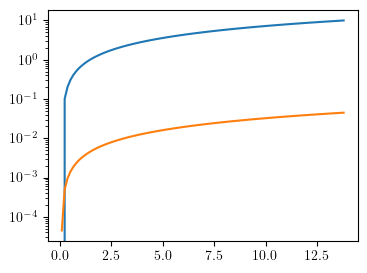

In [10]:
csp = CSPBasis(ssp_data)
forward_time = jnp.linspace(0.1, 13.78, 100)
sfh = jnp.linspace(0, 10, len(forward_time))
zh = jnp.linspace(min(csp.zlegend), max(csp.zlegend), len(forward_time))

plt.figure(figsize=(4, 3))
plt.plot(forward_time, sfh)
plt.plot(forward_time, zh)
plt.yscale('log')

In [21]:
csp.change_history(sfh = sfh, forward_time=forward_time, zh = zh)
spec = csp.get_spectrum()

def fnu2flam(lam,fnu): # fnu in erg/s/cm2/Hz
            c = 2.998e18 #A/s
            flam = c* fnu / lam**2
            return flam

(1e-17, 1e-10)

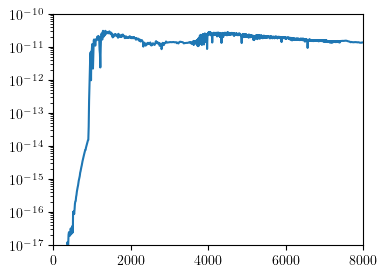

In [27]:
plt.figure(figsize=(4, 3))
plt.plot(csp.wave, fnu2flam(csp.wave, spec*3631*10**-23))
plt.yscale('log')
plt.xlim(0, 8000)
plt.ylim(1e-17, 1e-10)

In [26]:
import pandas as pd
dic = {'wave': csp.wave, 'flux': fnu2flam(csp.wave, spec*3631*10**-23), 'flux_fnu': spec}
df = pd.DataFrame(dic)  
df.to_csv('/Users/amanda/Desktop/PhD/Tools/ceridwen/data/test_data/spectra.csv', index=False)

In [ ]:
import pickle as pkl

pkl.dump('/Users/amanda/Desktop/PhD/Tools/ceridwen/data/test_data/spectra_fnu.pkl', )

Array([5.5098155e-28, 3.0550434e-27, 1.0077576e-26, ..., 7.5634854e-10,
       7.4251766e-10, 7.2891970e-10], dtype=float32)